In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
from model.metrics import accuracy,logloss,evaluate_binary_classifier
from model.gradients import logloss_sigmoid_grad
from model.utils import *
from model.activations import sigmoid
import matplotlib.pyplot as plt

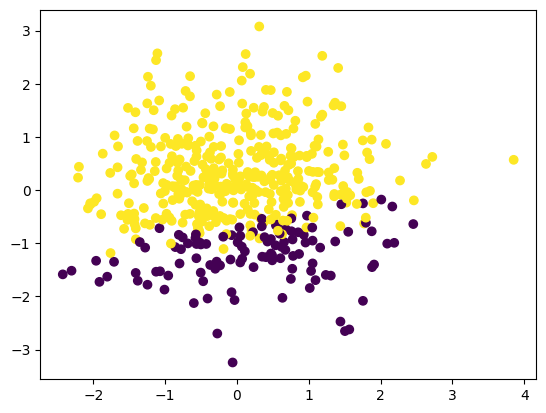

In [3]:
# Sample Code for generating datasets
seed=42
np.random.seed(seed)
size=500
seed=42
dim=2
noise_bound = 0.2
np.random.seed(seed)
X,y,W = generate_linear_dataset(size,dim,noise_bound=noise_bound,is_reg=False)
plt.scatter(X[:,1],X[:,2],c=y)

In [24]:
# loading data
loaded_data = np.load(f'data/logistic_data/logistic_data_A.npz')

X = loaded_data['X_data']
y = loaded_data['y_data']
W = loaded_data['W_data']
print(f"X size : {X.shape}, y size : {y.shape}")
size = X.shape[0]
dim = X.shape[1]-1

X size : (2000, 3), y size : (2000,)


20. Training loss: 0.7186495142074728, Val loss:0.7047936540731816
40. Training loss: 0.6878747425789467, Val loss:0.6754985050089182
60. Training loss: 0.6596571061876536, Val loss:0.6487042382586299
80. Training loss: 0.6338048966495962, Val loss:0.6242178833252007
100. Training loss: 0.6101273307147734, Val loss:0.6018476653461062
120. Training loss: 0.5884385786276475, Val loss:0.5814071712987692
140. Training loss: 0.5685608681068408, Val loss:0.562718546931649
160. Training loss: 0.550326684469274, Val loss:0.5456147379897462
180. Training loss: 0.5335801537156238, Val loss:0.5299408644132357
200. Training loss: 0.5181777338446021, Val loss:0.5155548620025148
220. Training loss: 0.5039883547757873, Val loss:0.502327545185001
240. Training loss: 0.4908931449026479, Val loss:0.49014224268451984
260. Training loss: 0.478784868547216, Val loss:0.47889414210934633
280. Training loss: 0.4675671788443642, Val loss:0.46848945644529294
300. Training loss: 0.45715376902762755, Val loss:0.4

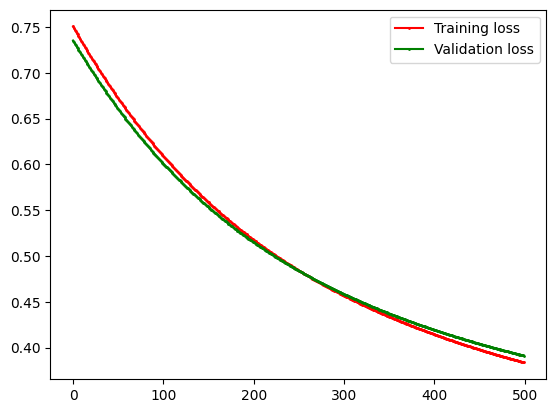

In [25]:
# Train
from model.linear_model import LinearModel
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad
X_train,y_train,X_val,y_val = get_train_val(X,y)
model = LinearModel(dim,False,loss_fn,grad_fn,act_fn)
model.fit(X_train,y_train,lr=0.01,n_iteration =500,val_ratio=0.2)

In [26]:
# Predict
y_pred = model.predict(X_val)

Logistic Regression Evaluation
  Accuracy: 0.8925
 Precision: 0.8884
    Recall: 0.9171
  F1-score: 0.9025


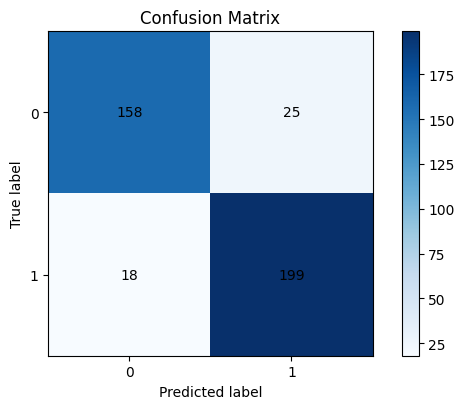

{'Accuracy': 0.8925,
 'Precision': 0.8883928571428571,
 'Recall': 0.9170506912442397,
 'F1-score': 0.9024943310657596}

In [ ]:
# Evaluation
# Please complete the evaluate_binary_classifier in the model/metrics.py by the sklearn package.
evaluate_binary_classifier(y_true=y_val,y_pred=y_pred,title='Logistic Regression Evaluation')

Plot validation set and decision boundary

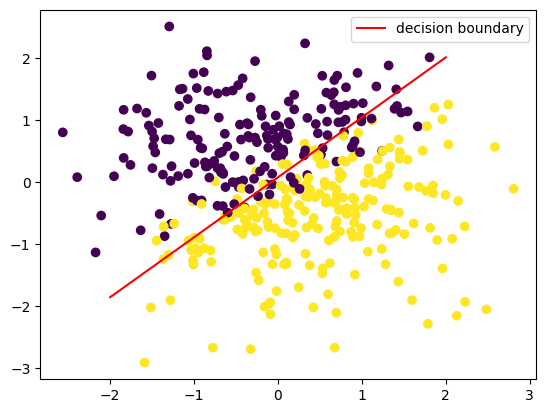

In [28]:
# Plot for logistic_data_A and logistic_data_B
plt.scatter(X_val[:,1],X_val[:,2],c=y_val)

ex1 = np.linspace(-2, 2, 100)
ex2 = -(model.W[1] * ex1 + model.W[0]) / model.W[2]

plt.plot(ex1, ex2, color='r', label='decision boundary')
plt.legend()
plt.show()